# SINDy-SHRED: Synthetic Data Example

This notebook demonstrates SINDy-SHRED on a synthetic toy dataset using the `SINDySHRED` class. The class handles data preprocessing, model training, and post-hoc SINDy discovery automatically.

## Overview

**SHRED** (SHallow REcurrent Decoder) models combine a recurrent layer (GRU) with a shallow decoder network to reconstruct high-dimensional spatio-temporal fields from sensor measurements.

**SINDy-SHRED** extends this by integrating Sparse Identification of Nonlinear Dynamics (SINDy) to learn interpretable governing equations:

$$\dot{z} = \Theta(z) \xi$$

## Synthetic Data

The synthetic data uses the **Van der Pol Model** with spatially delayed copies:

## Notebook Structure

1. Setup and Imports
2. Data Generation
3. Model Configuration and Training
4. SINDy Discovery
5. Evaluation
6. Save Results


## Issues
The latent space velocities are not estimated correctly when subsampling to make the calculations faster. This appears to be the root cause of being unable to identify the latent space. You can improve the discovered SINDy model by setting the substep in the toy model creation to be 50 instead of `50 * 8`. 

Secondly, there is an issue in recovering the spatial pattern. At the moment, SINDy-SHRED is unable to map to the spatially varying phase shift, which is weird since it does this for other problems without issue.

For now, this can just be used to verify consistency in the MIOSR and 2nd order properties of SINDy-SHRED.

## 1. Setup and Imports

In [1]:
import copy
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from scipy.integrate import solve_ivp

from sindy_shred import plotting

# Local modules
from sindy_shred.sindy_shred import SINDySHRED

warnings.filterwarnings("ignore")

# Create results directory
RESULTS_DIR = "results/synthetic_data"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: results/synthetic_data


### Device and Seed Configuration

In [2]:
# Device selection
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

# Set seeds for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed(SEED)

Using device: mps


### Plotting Configuration

In [3]:
sns.set_context("paper")
sns.set_style("whitegrid")

pcolor_kwargs = {
    "vmin": -3,
    "vmax": 3,
    "cmap": "RdBu_r",
    "rasterized": True,
}

## 2. Data Generation

Generate synthetic spatio-temporal data from the FitzHugh-Nagumo model with spatially delayed copies.

### Define Dynamical System

In [4]:
def rhs_vdp(t, z, tau, mu):
    s, u = z

    ds = u
    # du = (1 / tau) * (-2 * eta * u - s - epsilon * s**3)
    du = (1 / tau) * (mu * (1 - s**2) * u - s)
    return np.array([ds, du])

In [5]:
# Time integration parameters
T = 150
dt_solve = 0.0001
t_solution = np.arange(0, T, dt_solve)

# FitzHugh-Nagumo parameters
# x0 = np.array([0, 2])
x0 = np.array([-1, 1])
tau = 7
mu = 7

# Solve the ODE
solution_vdp = solve_ivp(rhs_vdp, [0, T], x0, t_eval=t_solution, args=(tau, mu))


print(f"Van der Pol solution shape: {solution_vdp.y.shape}")

# Create spatially delayed copies
num_space_dims = 40
delays = np.linspace(0, 3, num_space_dims)  # delays in time units
# uv_spatial = np.zeros((len(t_solution), 2 * num_space_dims))

s_spatial = np.zeros((len(t_solution), num_space_dims))

s_obs = solution_vdp.y[0, :]  # Extract position observations

for i in range(num_space_dims):
    delay_steps = int(delays[i] / dt_solve)
    if delay_steps == 0:
        s_spatial[:, i] = s_obs
    else:
        # Pad with initial condition and shift
        s_spatial[:, i] = np.concatenate([
            np.full(delay_steps, x0[0]),  # Use initial position
            s_obs[:-delay_steps]
        ])

# Subsample for computational efficiency
substep = 50 * 8
s_spatial = s_spatial[0::substep, :]
t_solution = t_solution[0::substep]

# Chop off the first part of the solution when the system is non-stationary.
t_solution = t_solution[num_space_dims:]
s_spatial = s_spatial[num_space_dims:, :]


time = t_solution
# Reset to 0
time = time - time[0]
dt_data = time[1] - time[0]

# Get dimensions
n_space_dims = s_spatial.shape[1]
n_time = s_spatial.shape[0]

# Final data matrix (space x time for visualization)
# data_original = uv_spatial.T
data_original = s_spatial.T
space_dim = np.arange(n_space_dims)

print(f"Data shape (space x time): {data_original.shape}")
print(f"Time step: {dt_data:.6f}")
print(f"Number of time samples: {n_time}")
print(f"Spatial dimension: {n_space_dims}")

Van der Pol solution shape: (2, 1500000)
Data shape (space x time): (40, 3710)
Time step: 0.040000
Number of time samples: 3710
Spatial dimension: 40


### Visualize Generated Data

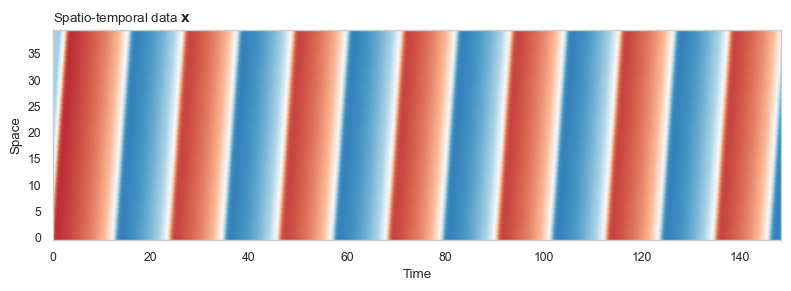

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.pcolormesh(time, space_dim, data_original, **pcolor_kwargs)
ax.set_title(r"Spatio-temporal data $\mathbf{x}$", loc="left")
ax.set_ylabel("Space")
ax.set_xlabel("Time")

fig.tight_layout()

# Save the data visualization plot
# fig.savefig(f"{RESULTS_DIR}/data_original.pdf", bbox_inches="tight", dpi=300)
# fig.savefig(f"{RESULTS_DIR}/data_original.png", bbox_inches="tight", dpi=300)
# print(f"Saved data plot to {RESULTS_DIR}/data_original.pdf")

plt.show()

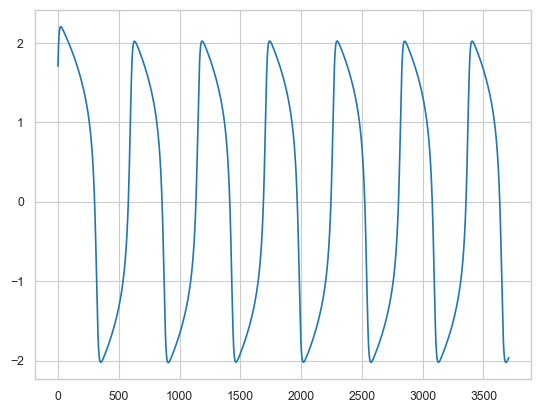

In [7]:
plt.plot(data_original[0])

## 3. Model Configuration and Training

Configure the SINDy-SHRED model using the `SINDySHRED` class.

### Data Configuration

In [8]:
# Sensor configuration (fixed for reproducibility)
# sensor_locations = np.array([5, 14, 37])
sensor_locations = np.array([5])
num_sensors = len(sensor_locations)

# Model hyperparameters
latent_dim = 1
poly_order = 2

# Prepare data (transpose to time x space, subsample)
load_X = copy.deepcopy(data_original)
subsample = 8
load_X = load_X.T[::subsample]  # Subsample
dt = dt_data * subsample
t_plot = time[::subsample]

# Data split configuration
lags = int(20 // dt)
train_length = int(time[-1] // 2 // dt)
validate_length = 0

# SINDy threshold
threshold = 0.0

print(f"Data shape after preprocessing: {load_X.shape}")
print(f"Number of sensors: {num_sensors}")
print(f"Latent dimension: {latent_dim}")
print(f"Trajectory length (lags): {lags}")
print(f"Training length: {train_length}")
print(f"Time step: {dt:.6f}")

Data shape after preprocessing: (464, 40)
Number of sensors: 1
Latent dimension: 1
Trajectory length (lags): 62
Training length: 231
Time step: 0.320000


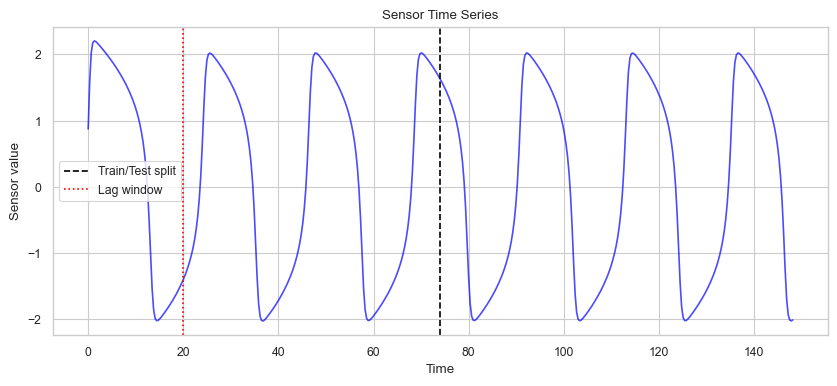

In [9]:
# Visualize sensor time series
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_plot, load_X[:, sensor_locations], color="b", alpha=0.7)
ax.axvline(t_plot[train_length], color="k", linestyle="--", label="Train/Test split")
ax.axvline(t_plot[lags], color="r", linestyle=":", label="Lag window")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor value")
ax.set_title("Sensor Time Series")
ax.legend()
plt.show()

### Initialize and Train Model

The `SINDySHRED` class handles data preprocessing and model training.

In [10]:
# Initialize the model
model = SINDySHRED(
    latent_dim=latent_dim,
    poly_order=poly_order,
    ode_order=2,  # 1st order ODE: z' = f(z), 2nd order ODE:
    num_epochs=600,
    verbose=True,
    device=device,
    threshold=threshold,
)

# Fit the model
model.fit(
    num_sensors, dt, load_X, lags, train_length, validate_length, sensor_locations
)

1 : tensor(0.3122, device='mps:0', grad_fn=<AddBackward0>)
2 : tensor(0.2282, device='mps:0', grad_fn=<AddBackward0>)
3 : tensor(0.2583, device='mps:0', grad_fn=<AddBackward0>)
4 : tensor(0.2426, device='mps:0', grad_fn=<AddBackward0>)
5 : tensor(0.2203, device='mps:0', grad_fn=<AddBackward0>)
6 : tensor(0.2154, device='mps:0', grad_fn=<AddBackward0>)
7 : tensor(0.2095, device='mps:0', grad_fn=<AddBackward0>)
8 : tensor(0.2061, device='mps:0', grad_fn=<AddBackward0>)
9 : tensor(0.2085, device='mps:0', grad_fn=<AddBackward0>)
10 : tensor(0.2098, device='mps:0', grad_fn=<AddBackward0>)
11 : tensor(0.2129, device='mps:0', grad_fn=<AddBackward0>)
12 : tensor(0.2067, device='mps:0', grad_fn=<AddBackward0>)
13 : tensor(0.2060, device='mps:0', grad_fn=<AddBackward0>)
14 : tensor(0.2018, device='mps:0', grad_fn=<AddBackward0>)
15 : tensor(0.1993, device='mps:0', grad_fn=<AddBackward0>)
16 : tensor(0.2007, device='mps:0', grad_fn=<AddBackward0>)
17 : tensor(0.1977, device='mps:0', grad_fn=<AddB

## 4. SINDy Discovery

Discover sparse governing equations from the learned latent space.

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2526320
Academic license 2526320 - for non-commercial use only - registered to ma___@uw.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2526320
Academic license 2526320 - for non-commercial use only - registered to ma___@uw.edu
SINDy-derived dynamical equation (2nd order, state-space form):

State: [z_0, ..., z_{n-1}, v_0, ..., v_{n-1}]
where v = dz/dt

(x0)' = 1.000 x1
(x1)' = -0.108 x0 + -0.049 x1 + 0.001 x0^2 + 0.103 x0 x1


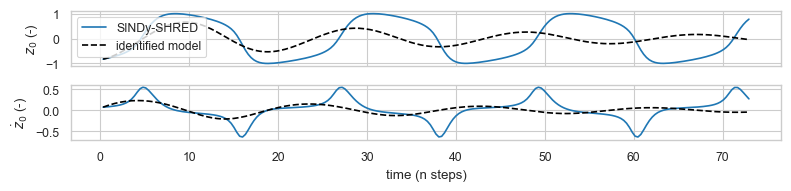

In [11]:
import importlib

os.chdir("/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/mr-SHRED/mr-SHRED/mr-SHRED")
import sindy_utils
importlib.reload(sindy_utils)
from sindy_utils import MIOSR


from sindy_shred import miosr_utils
importlib.reload(miosr_utils)

order = latent_dim * poly_order * model._ode_order
group_sparsity = np.ones(latent_dim) * order
group_sparsity = np.append(group_sparsity, np.ones(latent_dim) * order)

optimizer_kwargs = {"group_sparsity": group_sparsity} # "alpha": 0.05, 
optimizer = MIOSR
miosr_utils.sindy_identify(model, optimizer=optimizer, optimizer_kwargs=optimizer_kwargs)

In [12]:
miosr_utils.auto_tune_threshold(model, optimizer=optimizer, metric="bic")

Computing least-squares solution to determine threshold range...
Testing threshold=4.000... sparsity=8, stable, MSE=2.5610e-01
Testing threshold=5.000... sparsity=10, stable, MSE=2.5598e-01
Testing threshold=6.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=7.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=8.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=9.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=10.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=11.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=12.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=13.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=14.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=15.000... sparsity=12, stable, MSE=2.5621e-01

Best threshold: 4.000 (sparsity=8, MSE=2.5610e-01)
SINDy-derived dynamical equation (2nd order, state-space form):

State: [z_0, ..., z_{n-1}, v_0, ..., v_{n-1}]
where v = d

/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:191: UserWarning: Sparsity parameter is too big (4.0) and eliminated all coefficients
  warnings.warn(


(4.0,
 {'thresholds': array([ 4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15.]),
  'sparsity': array([ 8, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]),
  'stable': array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True]),
  'bic': array([-265.81620596, -255.07183531, -244.0232419 , -244.0232419 ,
         -244.0232419 , -244.0232419 , -244.0232419 , -244.0232419 ,
         -244.0232419 , -244.0232419 , -244.0232419 , -244.0232419 ]),
  'aic': array([-293.2158061 , -289.32133548, -285.1226421 , -285.1226421 ,
         -285.1226421 , -285.1226421 , -285.1226421 , -285.1226421 ,
         -285.1226421 , -285.1226421 , -285.1226421 , -285.1226421 ]),
  'mse': array([0.2561008 , 0.25598177, 0.25620593, 0.25620593, 0.25620593,
         0.25620593, 0.25620593, 0.25620593, 0.25620593, 0.25620593,
         0.25620593, 0.25620593]),
  'best_idx': 0})

## Comparing the SINDy-SHRED and original latent variables

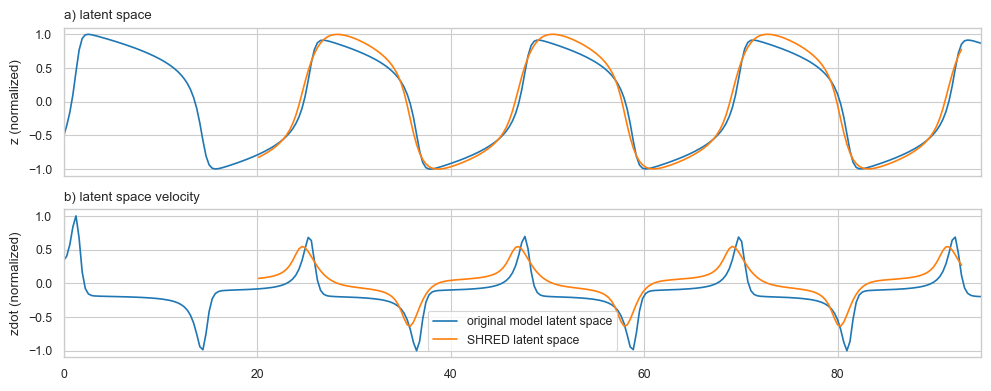

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

gru_outs = model.gru_normalize(data_type="train")
z = gru_outs.detach().cpu().numpy()
t_train = np.arange(0, len(z) * model._dt, model._dt) + lags * model._dt
x_state_trimmed, x_dot, z_trimmed, dz = model._get_2nd_order_state(z)

ax = axes[0]
v = solution_vdp.y.T[:len(time) * substep, 0]
v = v * (
    np.max(v) - np.min(v)
) + np.min(v)
v = (v - np.min(v)) / (np.max(v) - np.min(v))
v = 2 * v - 1
ax.plot(t_plot - t_plot[0], v[::subsample * substep])
ax.plot(t_train[1:-1], z_trimmed[:, 0])
ax.set_ylabel("z (normalized)")
ax.set_title("a) latent space", loc="left")

ax = axes[1]
vdot = solution_vdp.y.T[:len(time) * substep, 1]
vdot = vdot * (
    np.max(vdot) - np.min(vdot)
) + np.min(vdot)
vdot = (vdot - np.min(vdot)) / (np.max(vdot) - np.min(vdot))
vdot = 2 * vdot - 1
ax.plot(t_plot - t_plot[0], vdot[::subsample * substep], label="original model latent space")
ax.plot(t_train[1:-1], dz, label="SHRED latent space")
ax.set_title("b) latent space velocity", loc="left")
ax.legend()
ax.set_xlim(0, 75 + lags * model._dt)
ax.set_ylabel("zdot (normalized)")
fig.tight_layout()

SINDy-derived dynamical equation (2nd order, state-space form):

State: [z_0, ..., z_{n-1}, v_0, ..., v_{n-1}]
where v = dz/dt

(x0)' = 1.000 x1
(x1)' = 0.001 1 + -0.108 x0 + -0.049 x1 + 0.106 x0 x1 + -0.007 x1^2


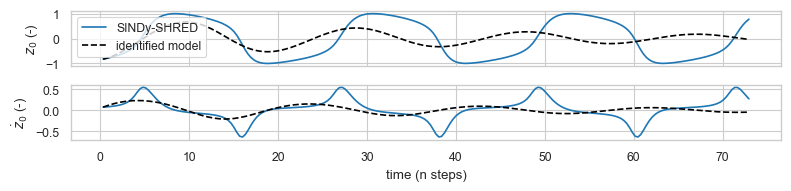

In [14]:
# Perform SINDy identification with automatic plot saving
model.sindy_identify(
    threshold=0., plot_result=True)

### Auto-Tune Threshold (Adaptive/Nonparametric)

Alternatively, use `auto_tune_threshold()` to automatically determine the best threshold.
By default it uses a nonparametric approach:
1. First computes the least-squares solution (threshold=0)
2. Uses `scale_factor * max(|coefficients|)` as the max threshold
3. Tests `n_thresholds` evenly spaced values and picks the best stable model

In [15]:
# os.chdir("/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/mr-SHRED/mr-SHRED/mr-SHRED")
# from sindy_utils import MIOSR

# order = 3
# group_sparsity = np.ones(latent_dim) * order
# group_sparsity = np.append(group_sparsity, np.ones(latent_dim) * order)

# optimizer_kwargs = {"alpha": 0.05, "group_sparsity": group_sparsity}
# optimizer = MIOSR

optimizer_kwargs = None
optimizer = None

# Auto-tune threshold using nonparametric approach
# This computes least-squares solution first, then determines threshold range adaptively
best_threshold, tune_results = model.auto_tune_threshold(
    adaptive=True,  # Use nonparametric approach (default)
    scale_factor=.2,  # Max threshold = 0.3 * max(|coefficients|)
    n_thresholds=10,  # Test 10 evenly spaced thresholds
    metric="sparsity_stable",  # Pick sparsest stable model
    verbose=True,
    optimizer=optimizer,
    optimizer_kwargs=optimizer_kwargs
)

print(f"\nBest threshold: {best_threshold:.4f}")
print(f"Tested thresholds: {tune_results['thresholds']}")
print(f"Sparsity at each: {tune_results['sparsity']}")
print(f"Stability at each: {tune_results['stable']}")

Computing least-squares solution to determine threshold range...
Max |coefficient|: 1.0000
Max threshold (scale_factor=0.2): 0.2000
Testing 10 thresholds: [0.         0.02222224 0.04444447 0.06666671 0.08888894 0.11111118
 0.13333341 0.15555565 0.17777788 0.20000012]
Testing threshold=0.000... sparsity=12, stable, MSE=2.5621e-01
Testing threshold=0.022... sparsity=4, stable, MSE=2.5647e-01
Testing threshold=0.044... sparsity=4, stable, MSE=2.5647e-01
Testing threshold=0.067... sparsity=3, stable, MSE=4.3621e-01
Testing threshold=0.089... sparsity=3, stable, MSE=4.3621e-01
Testing threshold=0.111... sparsity=1, stable, MSE=3.3355e+00
Testing threshold=0.133... sparsity=1, stable, MSE=3.3355e+00
Testing threshold=0.156... sparsity=1, stable, MSE=3.3355e+00
Testing threshold=0.178... sparsity=1, stable, MSE=3.3355e+00
Testing threshold=0.200... sparsity=1, stable, MSE=3.3355e+00

Best threshold: 0.111 (sparsity=1, MSE=3.3355e+00)
SINDy-derived dynamical equation (2nd order, state-space fo

/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.11111117733849421) and eliminated all coefficients
  warnings.warn(
/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.13333341280619304) and eliminated all coefficients
  warnings.warn(
/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.1555556482738919) and eliminated all coefficients
  warnings.warn(
/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.17777788374159073) and eliminated all coefficients
  warnings.warn(
/Users/karllapo/anaconda3/envs/sindy-shred/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsit

### True Governing Equations

For reference, the true governing equations are:

**FitzHugh-Nagumo Model:**
$$\dot{v} = v - \frac{1}{3}v^3 - w + 0.65$$
$$\dot{w} = \frac{1}{\tau}(v + 0.7 - 0.8w)$$

with time constant $\tau = 2$.

We recover a model that resembles the original model. A more accurate model for sensor reconstruction and prediction can be achieved using a lower threshold, but this model would admit additional governing terms that are not present in the original model and may represent an overfit. For this reason, the criterion weigh the information gained against the number of parameters required. Depending on your use case you may find different criteria important and one should weigh these trade-offs.

## 5. Evaluation

Evaluate reconstruction performance on the test set.

In [16]:
# Compute test reconstruction error using new API
test_recons = model.sensor_recon(data_type="test", return_scaled=False)
test_ground_truth = model._scaler.inverse_transform(
    model._test_data.Y.detach().cpu().numpy()
)

relative_error = model.relative_error(test_recons, test_ground_truth)
print(f"Test set relative reconstruction error: {relative_error:.4f}")

Test set relative reconstruction error: 0.3125


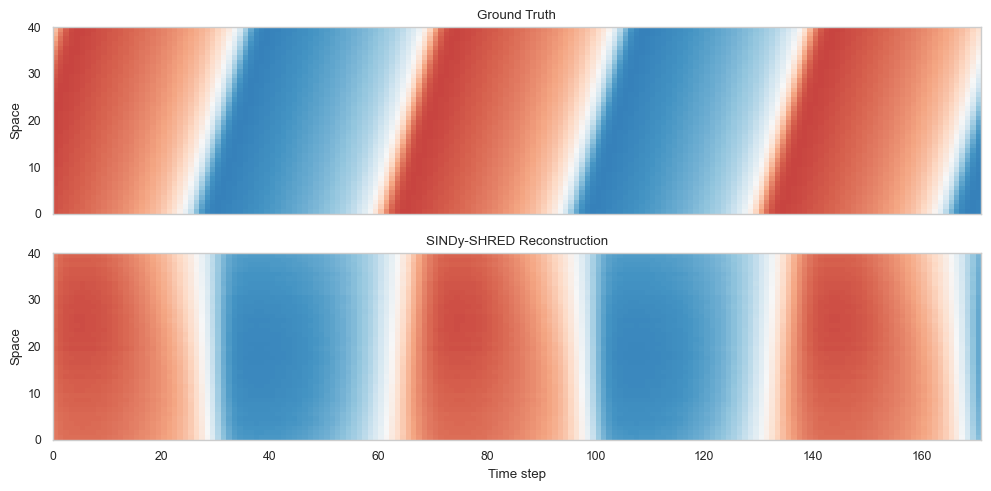

In [17]:
# Visualize reconstruction
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax = axes[0]
ax.pcolormesh(test_ground_truth.T, **pcolor_kwargs)
ax.set_title("Ground Truth")
ax.set_ylabel("Space")

ax = axes[1]
ax.pcolormesh(test_recons.T, **pcolor_kwargs)
ax.set_title("SINDy-SHRED Reconstruction")
ax.set_ylabel("Space")
ax.set_xlabel("Time step")

fig.tight_layout()

# # Save the reconstruction comparison plot
# fig.savefig(
#     f"{RESULTS_DIR}/reconstruction_comparison.pdf", bbox_inches="tight", dpi=300
# )
# fig.savefig(
#     f"{RESULTS_DIR}/reconstruction_comparison.png", bbox_inches="tight", dpi=300
# )
# print(
#     f"Saved reconstruction comparison plot to {RESULTS_DIR}/reconstruction_comparison.pdf"
# )

plt.show()

### Sensor-Level Predictions

Compare real vs predicted at individual spatial locations (sensors).

The **first approach** illustrates the overall work flow: 

- Predict the latent space by integrating the identified model forward in time. Initial condition is the last value of the training split's latent space trajectory.
- Pass the latent space trajectories through the shallow decoder in order to map to the higher dimensional space.
- Transform the higher dimensional data back to the original space.

This approach can also be used to predict other time periods.

The **second approach** combines all of the substeps from the first approach using a helper function.

SINDy prediction shape: (171, 1)
Decoded physical shape: (171, 40)


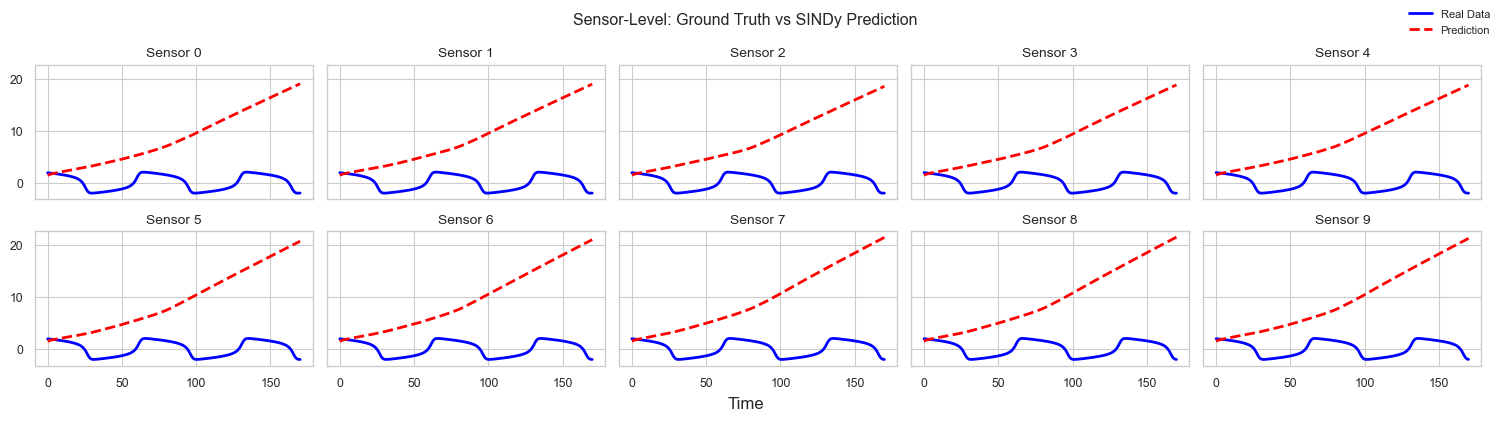

In [18]:
# 1st approach: Predict latent trajectories using SINDy model and decode to physical space
x_predict = model.predict_latent(split="train", init_from="last")  # SINDy prediction in latent space
sindy_physical = model.decode_to_physical(x_predict)  # Decode to physical space
sindy_physical = model._scaler.inverse_transform(sindy_physical)  # Unscale

# 2nd approach: Directly forecast from the last training point.
sindy_physical = model.forecast(return_scaled=False)

print(f"SINDy prediction shape: {x_predict.shape}")
print(f"Decoded physical shape: {sindy_physical.shape}")

# Plot sensor-level comparisons: Ground Truth vs SINDy Prediction
fig, axes = plotting.plot_sensor_predictions(
    test_ground_truth,
    sindy_physical[: len(test_ground_truth)],
    sensor_locations=np.arange(n_space_dims),  # All spatial dims
    rows=2,
    cols=5,
    # save_path=f"{RESULTS_DIR}/sensor_predictions_grid.pdf",
)
fig.suptitle("Sensor-Level: Ground Truth vs SINDy Prediction")
fig.tight_layout()
# print(f"Saved sensor predictions plot to {RESULTS_DIR}/sensor_predictions_grid.pdf")
plt.show()

## Summary

This notebook demonstrated SINDy-SHRED on synthetic FitzHugh-Nagumo data:

1. Generated toy data from FitzHugh-Nagumo model with spatial delays
2. Used the `SINDySHRED` class for streamlined model training
3. Discovered sparse governing equations that approximate the true dynamics
4. Achieved accurate reconstruction on held-out test data
5. **Saved all results** to the `results/synthetic_data/` folder

### Saved Files

| File | Description |
|------|-------------|
| `latent_train.npy` | Latent trajectories from training data |
| `latent_test.npy` | Latent trajectories from test data |
| `latent_sindy_predict.npy` | SINDy-predicted latent trajectories |
| `sindy_coefficients.npy` | Learned SINDy coefficient matrix |
| `sindy_feature_names.txt` | Names of SINDy library terms |
| `config.json` | Model configuration and hyperparameters |
| `results.json` | All error metrics (reconstruction, SINDy latent, SINDy prediction) |
| `*.pdf/*.png` | Visualization plots |

The `SINDySHRED` class simplifies the workflow compared to manual data preprocessing and model setup.

## 6. Save Results

Save the trained model, latent space values, and learned SINDy model to the results folder.

In [19]:
# import json
# import sys
# from io import StringIO

# # Get latent space trajectories
# gru_outs_train = model.gru_normalize(data_type="train")
# gru_outs_train_np = gru_outs_train.detach().cpu().numpy()

# gru_outs_test = model.gru_normalize(data_type="test")
# gru_outs_test_np = gru_outs_test.detach().cpu().numpy()

# # Save latent space trajectories
# np.save(f"{RESULTS_DIR}/latent_train.npy", gru_outs_train_np)
# np.save(f"{RESULTS_DIR}/latent_test.npy", gru_outs_test_np)
# np.save(f"{RESULTS_DIR}/latent_sindy_predict.npy", x_predict)
# print(f"Saved latent trajectories to {RESULTS_DIR}/latent_*.npy")

# # Save SINDy model coefficients
# sindy_coefficients = model._model.coefficients()
# np.save(f"{RESULTS_DIR}/sindy_coefficients.npy", sindy_coefficients)
# print(f"Saved SINDy coefficients to {RESULTS_DIR}/sindy_coefficients.npy")
# print(f"SINDy coefficients shape: {sindy_coefficients.shape}")

# # Save SINDy feature names
# feature_names = model._model.get_feature_names()
# with open(f"{RESULTS_DIR}/sindy_feature_names.txt", "w") as f:
#     for name in feature_names:
#         f.write(name + "\n")
# print(f"Saved SINDy feature names to {RESULTS_DIR}/sindy_feature_names.txt")

# # Save SINDy equations
# old_stdout = sys.stdout
# sys.stdout = StringIO()
# model._model.print()
# equations_str = sys.stdout.getvalue()
# sys.stdout = old_stdout

# with open(f"{RESULTS_DIR}/sindy_equations.txt", "w") as f:
#     f.write("Discovered SINDy Equations:\n")
#     f.write("=" * 40 + "\n")
#     f.write(equations_str)
# print(f"Saved SINDy equations to {RESULTS_DIR}/sindy_equations.txt")

# # Save configuration as JSON
# config = {
#     "latent_dim": latent_dim,
#     "poly_order": poly_order,
#     "num_sensors": num_sensors,
#     "lags": lags,
#     "train_length": train_length,
#     "validate_length": validate_length,
#     "dt": dt,
#     "threshold": threshold,
#     "best_threshold": float(best_threshold),
# }
# with open(f"{RESULTS_DIR}/config.json", "w") as f:
#     json.dump(config, f, indent=2)
# print(f"Saved configuration to {RESULTS_DIR}/config.json")

# # Compute additional errors for results
# # SINDy latent prediction error (training data)
# x_sim = model._x_sim
# z = model._gru_outs
# sindy_latent_error = np.linalg.norm(x_sim - z[: len(x_sim)]) / np.linalg.norm(
#     z[: len(x_sim)]
# )

# # SINDy physical prediction error (test data, use min length to handle shape mismatch)
# n_compare = min(len(sindy_physical), len(test_ground_truth))
# sindy_physical_error = np.linalg.norm(
#     sindy_physical[:n_compare] - test_ground_truth[:n_compare]
# ) / np.linalg.norm(test_ground_truth[:n_compare])

# # Save results as JSON
# results = {
#     "reconstruction_error": float(relative_error),
#     "sindy_latent_error": float(sindy_latent_error),
#     "sindy_prediction_error": float(sindy_physical_error),
# }
# with open(f"{RESULTS_DIR}/results.json", "w") as f:
#     json.dump(results, f, indent=2)
# print(f"Saved results to {RESULTS_DIR}/results.json")

# # Print summary of saved files
# print("\n" + "=" * 50)
# print("Saved files summary:")
# print("=" * 50)
# for f in sorted(os.listdir(RESULTS_DIR)):
#     fpath = os.path.join(RESULTS_DIR, f)
#     size = os.path.getsize(fpath)
#     print(f"  {f}: {size/1024:.1f} KB")